# 04 — Exploring BM Unit Matches

Three visualisations:
1. Scatter map of DUKES plants (filled = matched, hollow = unmatched)
2. Mekko barplot of DUKES capacity (accumulated x-axis, matched/unmatched fill)
3. Daily B1610 generation stacked area, unmixed by technology for matched BM units

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.dataset as ds

## 1  Load data

In [2]:
DATA = Path("../data")

dukes = pd.read_csv(DATA / "dukes_clean.csv")


# Parse capacity (strip whitespace/tabs) and sort descending — matches the order used in matches.json
def parse_capacity(val):
    try:
        return float(str(val).strip().replace(",", ""))
    except Exception:
        return None


dukes["capacity_mw"] = dukes["InstalledCapacity (MW)"].apply(parse_capacity)
dukes = dukes.sort_values("capacity_mw", ascending=False, na_position="last").reset_index(drop=True)

bm_cat = pd.read_parquet(DATA / "bm_unit_catalogue.parquet")
bm_missing = pd.read_parquet(DATA / "missing_bm_unit_details.parquet")
matches = pd.read_csv(DATA / "matches.csv")[["dukes_site_name", "bm_unit_id"]]

print(f"DUKES plants: {len(dukes)}")
print(f"BM catalogue: {len(bm_cat)}")
print(f"Missing BM details: {len(bm_missing)}")
print(f"Match rows (BM unit × site): {len(matches)}")
print(f"DUKES row 0: {dukes.iloc[0]['Site Name']} ({dukes.iloc[0]['capacity_mw']} MW)")

DUKES plants: 1369
BM catalogue: 2903
Missing BM details: 1242
Match rows (BM unit × site): 432
DUKES row 0: Drax Power Station Biomass Units (2580.0 MW)


## 2  Technology → colour mapping

In [3]:
TECH_COLORS = {
    "bioenergy": "saddlebrown",
    "nuclear": "purple",
    "hydro": "royalblue",
    "pumped-hydro": "cyan",
    "solar": "gold",
    "wind": "limegreen",
    "fossil-fuel/CCGT": "black",
    "OCGT": "dimgray",
    "other": "lightgray",
}


def dukes_tech_category(row) -> str:
    """Map DUKES Technology + Type columns to a colour-category key."""
    tech = str(row.get("Technology", "")).lower()
    typ = str(row.get("Type", "")).lower()
    if tech == "nuclear":
        return "nuclear"
    if "pumped" in tech or "pumped" in typ:
        return "pumped-hydro"
    if tech == "hydro" or "hydro" in typ:
        return "hydro"
    if tech == "solar":
        return "solar"
    if tech == "wind":
        return "wind"
    if tech == "bioenergy":
        return "bioenergy"
    if tech == "fossil fuel":
        if "single cycle" in typ or "ocgt" in typ:
            return "OCGT"
        return "fossil-fuel/CCGT"  # CCGT, conventional steam, etc.
    return "other"


dukes["tech_cat"] = dukes.apply(dukes_tech_category, axis=1)
dukes["tech_cat"].value_counts()

tech_cat
solar               662
wind                488
hydro               125
fossil-fuel/CCGT     34
OCGT                 32
bioenergy            19
nuclear               5
pumped-hydro          4
Name: count, dtype: int64

## 3  Build match lookups

In [4]:
# Build site-name → DUKES positional index lookup (strip trailing whitespace from DUKES names)
site_name_to_idx = {row["Site Name"].strip(): idx for idx, row in dukes.iterrows()}

# Build BM unit → DUKES index, and track which DUKES indices are matched
bm_unit_to_dukes_idx: dict[str, int] = {}
matched_dukes_idx: set[int] = set()

for _, row in matches.iterrows():
    dukes_idx = site_name_to_idx.get(row["dukes_site_name"].strip())
    if dukes_idx is None:
        print(f"WARNING: no DUKES row found for site '{row['dukes_site_name']}'")
        continue
    bm_unit_to_dukes_idx[row["bm_unit_id"]] = dukes_idx
    matched_dukes_idx.add(dukes_idx)

dukes["matched"] = dukes.index.isin(matched_dukes_idx)

print(f"Matched DUKES plants:  {dukes['matched'].sum()}")
print(f"Matched BM units:      {len(bm_unit_to_dukes_idx)}")
print(f"Unmatched DUKES plants:{(~dukes['matched']).sum()}")

Matched DUKES plants:  268
Matched BM units:      386
Unmatched DUKES plants:1101


## 4  Plot 1 — Scatter map of DUKES plants

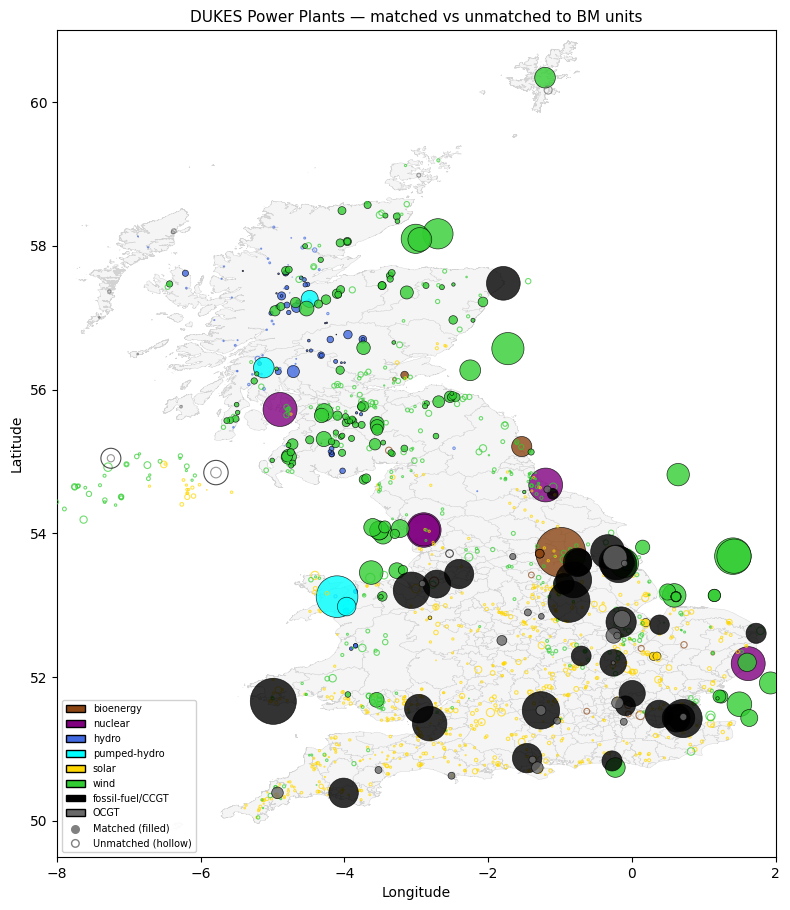

In [5]:
uk = gpd.read_file(
    "https://raw.githubusercontent.com/martinjc/UK-GeoJSON/master/json/administrative/gb/topo_lad.json"
)

# Drop rows without coordinates
dukes_geo = dukes.dropna(subset=["Latitude", "Longitude"]).copy()
dukes_geo = dukes_geo[dukes_geo["Latitude"] != 0]

fig, ax = plt.subplots(figsize=(8, 10))
uk.plot(ax=ax, color="whitesmoke", edgecolor="lightgray", linewidth=0.3)

size_scale = 0.5  # point size per MW

for tech, color in TECH_COLORS.items():
    subset = dukes_geo[dukes_geo["tech_cat"] == tech]
    if subset.empty:
        continue
    matched = subset[subset["matched"]]
    unmatched = subset[~subset["matched"]]

    # Filled = matched
    if not matched.empty:
        ax.scatter(
            matched["Longitude"],
            matched["Latitude"],
            s=matched["capacity_mw"] * size_scale,
            c=color,
            alpha=0.8,
            linewidths=0.5,
            edgecolors="k",
            zorder=3,
        )
    # Hollow = unmatched
    if not unmatched.empty:
        ax.scatter(
            unmatched["Longitude"],
            unmatched["Latitude"],
            s=unmatched["capacity_mw"] * size_scale,
            facecolors="none",
            edgecolors=color,
            linewidths=0.8,
            alpha=0.7,
            zorder=3,
        )

# Legend
legend_handles = [
    mpatches.Patch(facecolor=c, edgecolor="k", label=t)
    for t, c in TECH_COLORS.items()
    if t != "other"
]
legend_handles += [
    plt.scatter([], [], c="gray", s=30, label="Matched (filled)"),
    plt.scatter([], [], facecolors="none", edgecolors="gray", s=30, label="Unmatched (hollow)"),
]
ax.legend(handles=legend_handles, loc="lower left", fontsize=7, framealpha=0.9)

ax.set_xlim(-8, 2)
ax.set_ylim(49.5, 61)
ax.set_title("DUKES Power Plants — matched vs unmatched to BM units", fontsize=11)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

## 5  Plot 2 — Mekko barplot (capacity distribution)

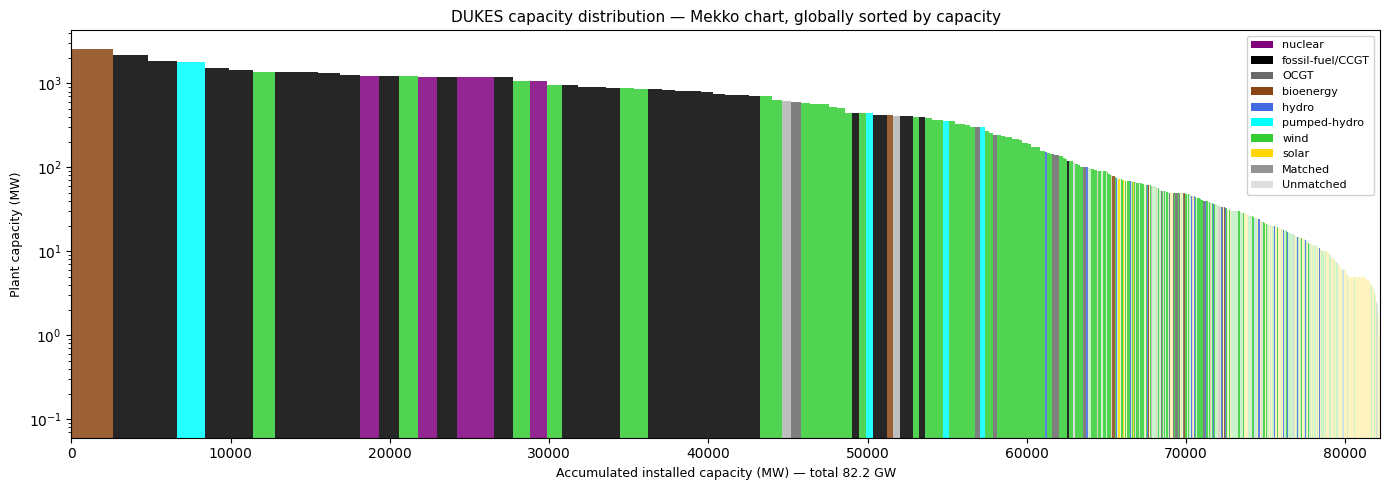

In [6]:
# Sort globally by capacity descending
dukes_mekko = dukes.dropna(subset=["capacity_mw"]).copy()
dukes_mekko = dukes_mekko.sort_values("capacity_mw", ascending=False).reset_index(drop=True)
dukes_mekko["x_left"] = dukes_mekko["capacity_mw"].cumsum().shift(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))

for _, row in dukes_mekko.iterrows():
    color = TECH_COLORS.get(row["tech_cat"], "lightgray")
    alpha = 0.85 if row["matched"] else 0.25
    ax.bar(
        row["x_left"],
        row["capacity_mw"],
        width=row["capacity_mw"],
        align="edge",
        color=color,
        edgecolor="none",
        alpha=alpha,
    )

# Legend
TECH_ORDER = [
    "nuclear",
    "fossil-fuel/CCGT",
    "OCGT",
    "bioenergy",
    "hydro",
    "pumped-hydro",
    "wind",
    "solar",
    "other",
]
legend_handles = [
    mpatches.Patch(facecolor=TECH_COLORS[t], edgecolor="none", label=t)
    for t in TECH_ORDER
    if t in dukes_mekko["tech_cat"].values
]
legend_handles += [
    mpatches.Patch(facecolor="gray", alpha=0.85, edgecolor="none", label="Matched"),
    mpatches.Patch(facecolor="gray", alpha=0.25, edgecolor="none", label="Unmatched"),
]
ax.legend(handles=legend_handles, loc="upper right", fontsize=8, framealpha=0.9)

total_gw = dukes_mekko["capacity_mw"].sum() / 1e3
ax.set_xlim(0, dukes_mekko["capacity_mw"].sum())
ax.set_xlabel(f"Accumulated installed capacity (MW) — total {total_gw:.1f} GW", fontsize=9)
ax.set_ylabel("Plant capacity (MW)", fontsize=9)
ax.set_title("DUKES capacity distribution — Mekko chart, globally sorted by capacity", fontsize=11)
ax.set_yscale("log")
plt.tight_layout()
plt.show()

## 6  Build B1610 series labels

In [7]:
# Map fuelType in Elexon catalogue → tech_cat colour keys
FUELTYPE_MAP = {
    "BIOMASS": "bioenergy",
    "CCGT": "fossil-fuel/CCGT",
    "COAL": "fossil-fuel/CCGT",
    "NUCLEAR": "nuclear",
    "NPSHYD": "hydro",
    "PS": "pumped-hydro",
    "WIND": "wind",
    "OCGT": "OCGT",
    "OTHER": "other",
    "INTELEC": "interconnector",
    "INTEW": "interconnector",
    "INTFR": "interconnector",
    "INTGRNL": "interconnector",
    "INTIFA2": "interconnector",
    "INTIRL": "interconnector",
    "INTNED": "interconnector",
    "INTNEM": "interconnector",
    "INTNSL": "interconnector",
    "INTVKL": "interconnector",
}

TECH_COLORS["interconnector"] = "orangered"

TYPE_MAPPING = {
    "M": "misc",
    "E": "embedded",
    "I": "interconnector",
    "T": "direct",
    "2": "supplier",
    "C": "supplier",
    "V": "virtual",
}

# Build a label lookup: elexonBmUnit → series label (str)
cat_label_df = bm_cat[["elexonBmUnit", "fuelType"]].copy()


def _make_label(r):
    if r["elexonBmUnit"] in bm_unit_to_dukes_idx:
        dukes_idx = bm_unit_to_dukes_idx[r["elexonBmUnit"]]
        tech = dukes.loc[dukes_idx, "tech_cat"]
        return f"matched_{tech}"
    mapped = FUELTYPE_MAP.get(r["fuelType"])
    if mapped:
        return f"unmatched_{mapped}"
    bm_type = TYPE_MAPPING[
        r["elexonBmUnit"][0]
    ]  # intentional KeyError if first char is unexpected, to catch unmapped types
    return f"unmatched_{bm_type}"


cat_label_df["series"] = cat_label_df.apply(_make_label, axis=1)
bm_label_lookup = dict(zip(cat_label_df["elexonBmUnit"], cat_label_df["series"]))

print("Series categories:", sorted(set(bm_label_lookup.values())))

Series categories: ['matched_OCGT', 'matched_bioenergy', 'matched_fossil-fuel/CCGT', 'matched_hydro', 'matched_nuclear', 'matched_pumped-hydro', 'matched_solar', 'matched_wind', 'unmatched_OCGT', 'unmatched_bioenergy', 'unmatched_direct', 'unmatched_embedded', 'unmatched_fossil-fuel/CCGT', 'unmatched_hydro', 'unmatched_interconnector', 'unmatched_nuclear', 'unmatched_other', 'unmatched_supplier', 'unmatched_virtual', 'unmatched_wind']


## 7  Load B1610 data and aggregate

In [32]:
# Load all B1610 parquet files with pyarrow, join series label, aggregate daily GWh
b1610_dataset = ds.dataset(DATA / "b1610", format="parquet")

b1610 = b1610_dataset.to_table(columns=["bmUnit", "settlementDate", "quantity"]).to_pandas()
print(f"B1610 rows loaded: {len(b1610):,}")

# Assign series label; unmapped units (not in catalogue) → unmatched_other
b1610["series"] = b1610["bmUnit"].map(bm_label_lookup).fillna("unmatched_other")
b1610["mwh"] = b1610["quantity"] * 0.5  # MW × 0.5 h → MWh

# Positive quantities (generation + interconnector export) → stacked above axis
# Negative quantities (demand, pumping, interconnector import) → stacked below axis
b1610_pos = b1610[b1610["mwh"] > 0]
b1610_neg = b1610[b1610["mwh"] < 0]


def daily_pivot(df):
    piv = (
        df.groupby(["settlementDate", "series"])["mwh"].sum().unstack(fill_value=0) / 1e3  # → GWh
    )
    piv.index = pd.to_datetime(piv.index)
    return piv.sort_index()


daily_pos = daily_pivot(b1610_pos)
daily_neg = daily_pivot(b1610_neg)

print("Positive series:", daily_pos.columns.tolist())
print("Negative series:", daily_neg.columns.tolist())

B1610 rows loaded: 21,861,504
Positive series: ['matched_OCGT', 'matched_bioenergy', 'matched_fossil-fuel/CCGT', 'matched_hydro', 'matched_nuclear', 'matched_pumped-hydro', 'matched_solar', 'matched_wind', 'unmatched_OCGT', 'unmatched_bioenergy', 'unmatched_direct', 'unmatched_embedded', 'unmatched_fossil-fuel/CCGT', 'unmatched_hydro', 'unmatched_interconnector', 'unmatched_other', 'unmatched_supplier', 'unmatched_virtual', 'unmatched_wind']
Negative series: ['matched_OCGT', 'matched_bioenergy', 'matched_fossil-fuel/CCGT', 'matched_hydro', 'matched_nuclear', 'matched_pumped-hydro', 'matched_solar', 'matched_wind', 'unmatched_OCGT', 'unmatched_bioenergy', 'unmatched_direct', 'unmatched_embedded', 'unmatched_fossil-fuel/CCGT', 'unmatched_hydro', 'unmatched_interconnector', 'unmatched_other', 'unmatched_supplier', 'unmatched_virtual', 'unmatched_wind']


## 8  Plot 3 — Daily B1610 generation stacked area

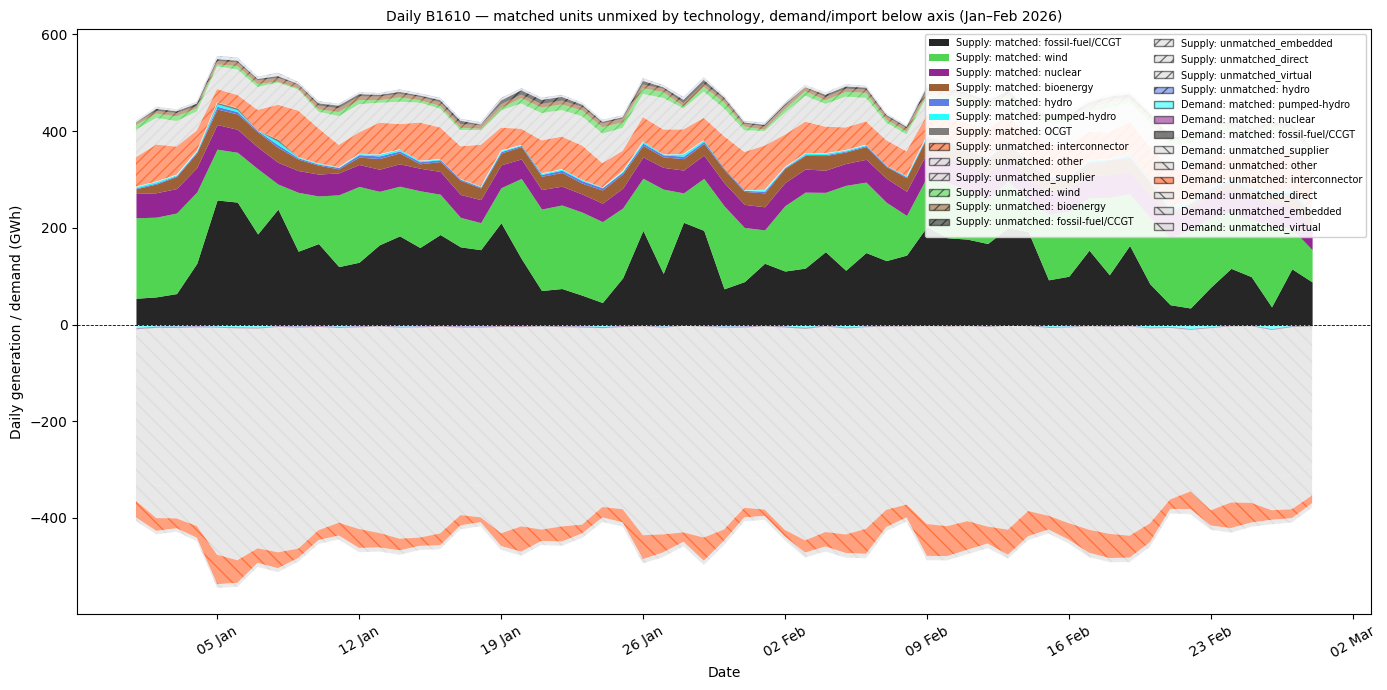

In [41]:
# Build colour + display order for stacked area
SERIES_COLOR = {}
SERIES_LABEL = {}

for tech, color in TECH_COLORS.items():
    SERIES_COLOR[f"matched_{tech}"] = color
    SERIES_COLOR[f"unmatched_{tech}"] = color
    SERIES_LABEL[f"matched_{tech}"] = f"matched: {tech}"
    SERIES_LABEL[f"unmatched_{tech}"] = f"unmatched: {tech}"

SERIES_COLOR["unmatched_other"] = "lightgray"
SERIES_LABEL["unmatched_other"] = "unmatched: other"

MIN_GWH = 10


def ordered_columns(daily):
    matched = sorted(
        [c for c in daily.columns if c.startswith("matched_")], key=lambda c: -daily[c].abs().sum()
    )
    unmatched = sorted(
        [c for c in daily.columns if c.startswith("unmatched_")],
        key=lambda c: -daily[c].abs().sum(),
    )
    return matched + unmatched


all_dates = daily_pos.index.union(daily_neg.index)
daily_pos = daily_pos.reindex(all_dates, fill_value=0)
daily_neg = daily_neg.reindex(all_dates, fill_value=0)

fig, ax = plt.subplots(figsize=(14, 7))

legend_seen = set()
legend_handles = []

# --- Positive stack (above axis) ---
bottoms_pos = np.zeros(len(all_dates))
for col in ordered_columns(daily_pos):
    vals = daily_pos[col].values if col in daily_pos.columns else np.zeros(len(all_dates))
    if np.abs(vals).sum() < MIN_GWH:
        continue
    color = SERIES_COLOR.get(col, "lightgray")
    label = "Supply: " + SERIES_LABEL.get(col, col)
    is_matched = col.startswith("matched_")
    hatch = None if is_matched else "///"
    ax.fill_between(
        all_dates,
        bottoms_pos,
        bottoms_pos + vals,
        color=color,
        alpha=0.85 if is_matched else 0.5,
        linewidth=0,
        hatch=hatch,
    )
    if label not in legend_seen:
        legend_handles.append(
            mpatches.Patch(
                facecolor=color,
                alpha=0.85 if is_matched else 0.5,
                hatch=hatch,
                edgecolor="k" if not is_matched else "none",
                label=label,
            )
        )
        legend_seen.add(label)
    bottoms_pos = bottoms_pos + vals

# --- Negative stack (below axis) ---
bottoms_neg = np.zeros(len(all_dates))
for col in ordered_columns(daily_neg):
    vals = daily_neg[col].values if col in daily_neg.columns else np.zeros(len(all_dates))
    if np.abs(vals).sum() < MIN_GWH:
        continue
    color = SERIES_COLOR.get(col, "lightgray")
    label = "Demand: " + SERIES_LABEL.get(col, col)
    is_matched = col.startswith("matched_")
    hatch = None if is_matched else "\\\\"
    ax.fill_between(
        all_dates, bottoms_neg + vals, bottoms_neg, color=color, alpha=0.5, linewidth=0, hatch=hatch
    )
    if label not in legend_seen:
        legend_handles.append(
            mpatches.Patch(
                facecolor=color,
                alpha=0.5,
                hatch=hatch,
                edgecolor="k",
                label=label,
            )
        )
        legend_seen.add(label)
    bottoms_neg = bottoms_neg + vals

ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.legend(handles=legend_handles, loc="upper right", fontsize=7, framealpha=0.9, ncol=2)
ax.set_xlabel("Date")
ax.set_ylabel("Daily generation / demand (GWh)")
ax.set_title(
    "Daily B1610 — matched units unmixed by technology, demand/import below axis (Jan–Feb 2026)",
    fontsize=10,
)
ax.xaxis.set_major_locator(plt.matplotlib.dates.WeekdayLocator(byweekday=0))
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%d %b"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()